# Pytorch with the MNIST Dataset - MINST

In [33]:
## import libraries
from __future__ import print_function
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable

import numpy as np
import pandas as pd
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    brier_score_loss, f1_score
)
from sklearn.calibration import calibration_curve
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
print(torch.__version__)

2.8.0+cu126


In [35]:
# downloading dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Path to dataset files: /kaggle/input/heart-failure-prediction


In [36]:
# Load the data
data = pd.read_csv(path + '/heart.csv')

# Pick target column and feature columns
target = "HeartDisease"
y = data[target]

# numeric and categorical input columns
num_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
X = data.drop(target, axis=1)

In [37]:
# Preprocess + Model Pipeline

# filling in any null values in numerical columns
X[num_cols] = X[num_cols].fillna(X[num_cols].mean())

# filling in any null values in categorical columns
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])


# Need to standardize numeric features
# One hot encode categorical features
# Linear regression outputs a continuous score, so we will use a threshold
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)


In [38]:
# Train/test split (stratified using target column)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=27
)

In [39]:
# Full pipeline: preprocessing + logistic regression
logRegSM = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200))
])

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# try different regularization penalities and solvers to find the best combination
param_grid = [
    {
        "classifier__solver": ["lbfgs", "newton-cg"],
        "classifier__penalty": ["l2"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "classifier__solver": ["saga"],
        "classifier__penalty": ["l1", "l2"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
    }
]

grid = GridSearchCV(logRegSM, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' w

Best Params: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV Accuracy: 0.8605416269967205


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). 

In [41]:
best_model = grid.best_estimator_

In [50]:
# Evaluate on the test set with the tuned threshold
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))

Accuracy: 0.8782608695652174
ROC-AUC: 0.9364727467319012

Confusion Matrix:
 [[ 87  16]
 [ 12 115]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86       103
           1       0.88      0.91      0.89       127

    accuracy                           0.88       230
   macro avg       0.88      0.88      0.88       230
weighted avg       0.88      0.88      0.88       230



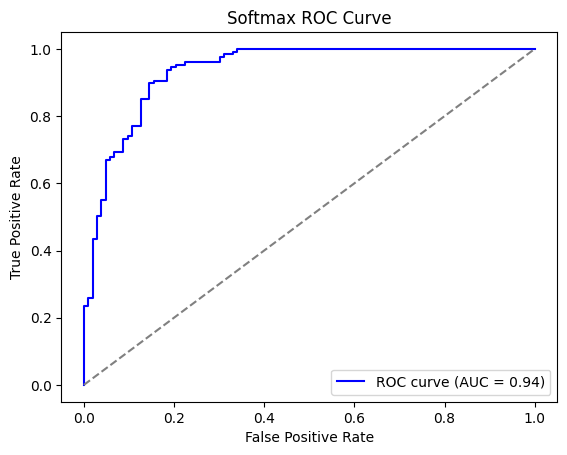

In [48]:
# Create ROC Curve
y_score = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Softmax ROC Curve")
plt.legend(loc="lower right")
plt.show()